# Discrete Fourier Transform (DFT) in Python

This notebook dives deep into the **Discrete Fourier Transform** from first principles. We will cover:

- The mathematical definition and intuition behind DFT
- Manual implementation using the DFT matrix
- Frequency bins, resolution, and the Nyquist limit
- Properties: linearity, periodicity, conjugate symmetry
- Magnitude, phase, and reconstruction via Inverse DFT
- Circular convolution and the DFT multiplication property
- Spectral leakage and windowing
- Zero-padding and interpolation in the frequency domain

**Requirements:** `numpy`, `matplotlib`, `scipy`


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq, fftshift
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10


## 1. Mathematical Definition

Given a discrete signal $x[n]$ of length $N$, the **DFT** is defined as:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j \frac{2\pi}{N} k n}, \quad k = 0, 1, \dots, N-1$$

The **Inverse DFT (IDFT)** reconstructs the original signal:

$$x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] \cdot e^{j \frac{2\pi}{N} k n}, \quad n = 0, 1, \dots, N-1$$

The term $W_N^{kn} = e^{-j \frac{2\pi}{N} k n}$ is called the **twiddle factor**. It represents a point on the unit circle in the complex plane, rotated by angle $\frac{2\pi}{N}kn$.


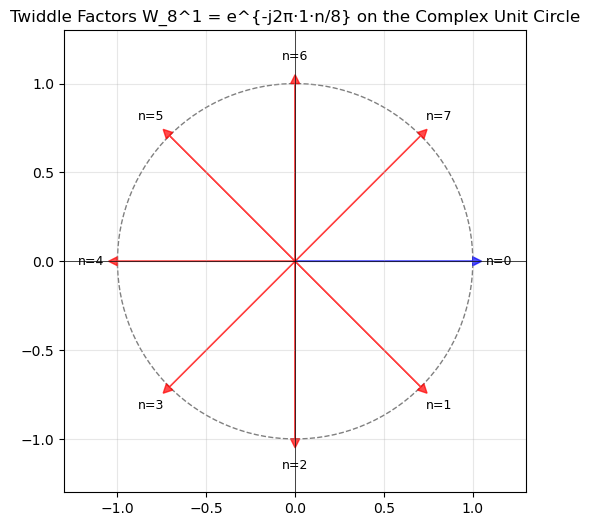

In [27]:
# Visualize the twiddle factors W_N^k for N=8
N = 8
k = 1  # First harmonic

fig, ax = plt.subplots(figsize=(6, 6))
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--')
ax.add_patch(circle)

for n in range(N):
    angle = -2 * np.pi * k * n / N
    real = np.cos(angle)
    imag = np.sin(angle)
    color = 'blue' if n == 0 else 'red'
    ax.arrow(0, 0, real, imag, head_width=0.05, head_length=0.05, fc=color, ec=color, alpha=0.7)
    ax.text(real*1.15, imag*1.15, f'n={n}', ha='center', va='center', fontsize=9)

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title(f'Twiddle Factors W_{N}^{k} = e^{{-j2π·{k}·n/{N}}} on the Complex Unit Circle')
ax.grid(True, alpha=0.3)
plt.show()


## 2. Manual DFT Implementation

Before using `numpy.fft`, let's implement the DFT manually using the summation formula. This builds intuition for what the algorithm actually does: it correlates the input signal with complex exponentials of different frequencies.


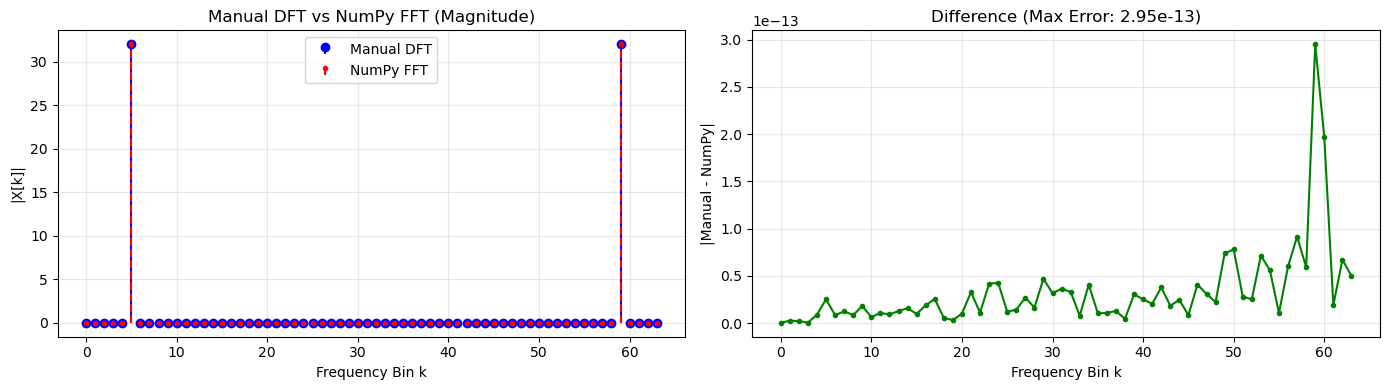

Max difference between manual and NumPy: 2.95e-13


In [28]:
def dft_manual(x):
    """Compute DFT manually using the direct summation formula."""
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            angle = -2j * np.pi * k * n / N
            X[k] += x[n] * np.exp(angle)
    return X

def idft_manual(X):
    """Compute Inverse DFT manually."""
    N = len(X)
    x = np.zeros(N, dtype=complex)
    for n in range(N):
        for k in range(N):
            angle = 2j * np.pi * k * n / N
            x[n] += X[k] * np.exp(angle)
    return x / N

# Test with a simple signal
N = 64
n = np.arange(N)
x_test = np.cos(2 * np.pi * 5 * n / N)  # Exactly 5 cycles in N samples

X_manual = dft_manual(x_test)
X_numpy = fft(x_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].stem(np.abs(X_manual), basefmt=' ', linefmt='b-', markerfmt='bo', label='Manual DFT')
axes[0].stem(np.abs(X_numpy), basefmt=' ', linefmt='r--', markerfmt='r.', label='NumPy FFT')
axes[0].set_title('Manual DFT vs NumPy FFT (Magnitude)')
axes[0].set_xlabel('Frequency Bin k')
axes[0].set_ylabel('|X[k]|')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Verify they match
diff = np.max(np.abs(X_manual - X_numpy))
axes[1].plot(np.abs(X_manual - X_numpy), 'g-o', markersize=3)
axes[1].set_title(f'Difference (Max Error: {diff:.2e})')
axes[1].set_xlabel('Frequency Bin k')
axes[1].set_ylabel('|Manual - NumPy|')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max difference between manual and NumPy: {diff:.2e}")


## 3. The DFT Matrix

The DFT can be expressed as a matrix-vector multiplication:

$$\mathbf{X} = \mathbf{W} \cdot \mathbf{x}$$

Where $\mathbf{W}$ is the $N \times N$ DFT matrix with elements $W_{k,n} = e^{-j \frac{2\pi}{N} k n}$. This is elegant but computationally expensive ($O(N^2)$) compared to the FFT ($O(N \log N)$).


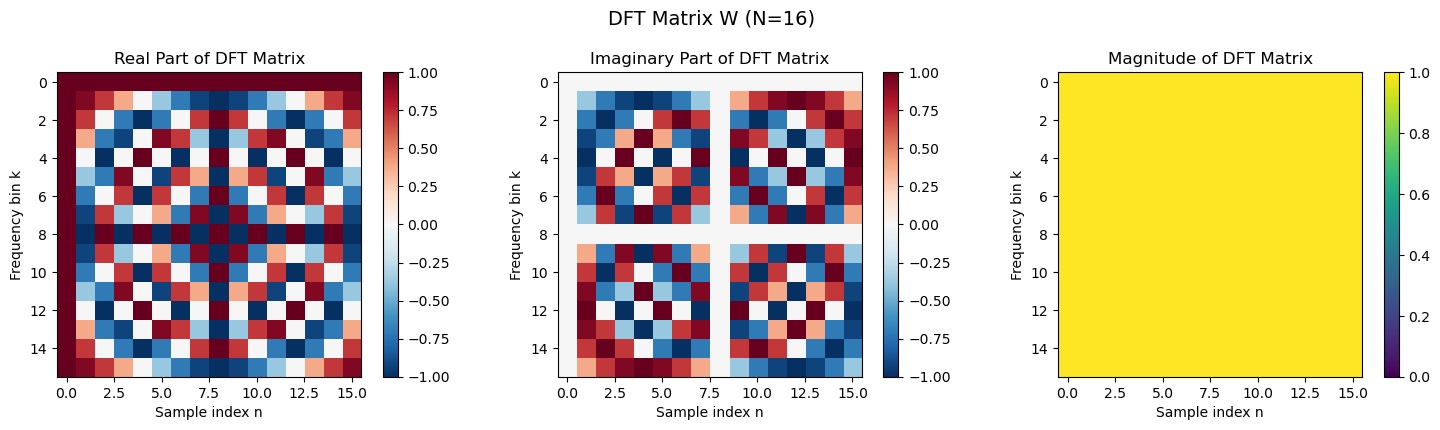

Matrix DFT matches FFT: True


In [29]:
def dft_matrix(N):
    """Generate the NxN DFT matrix."""
    n = np.arange(N).reshape((N, 1))
    k = np.arange(N).reshape((1, N))
    W = np.exp(-2j * np.pi * k * n / N)
    return W

N = 16
W = dft_matrix(N)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Real part
im1 = axes[0].imshow(np.real(W), cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Real Part of DFT Matrix')
axes[0].set_xlabel('Sample index n')
axes[0].set_ylabel('Frequency bin k')
fig.colorbar(im1, ax=axes[0])

# Imaginary part
im2 = axes[1].imshow(np.imag(W), cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title('Imaginary Part of DFT Matrix')
axes[1].set_xlabel('Sample index n')
axes[1].set_ylabel('Frequency bin k')
fig.colorbar(im2, ax=axes[1])

# Magnitude
im3 = axes[2].imshow(np.abs(W), cmap='viridis', vmin=0, vmax=1)
axes[2].set_title('Magnitude of DFT Matrix')
axes[2].set_xlabel('Sample index n')
axes[2].set_ylabel('Frequency bin k')
fig.colorbar(im3, ax=axes[2])

plt.suptitle(f'DFT Matrix W (N={N})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Verify: W @ x should equal fft(x)
x_vec = np.random.randn(N)
X_mat = W @ x_vec
X_fft = fft(x_vec)
print(f"Matrix DFT matches FFT: {np.allclose(X_mat, X_fft)}")


## 4. Frequency Bins and Resolution

The DFT maps $N$ time-domain samples to $N$ frequency-domain bins. The mapping between bin index $k$ and physical frequency $f$ is:

$$f_k = k \cdot \frac{f_s}{N}$$

Where $f_s$ is the sampling rate. The **frequency resolution** is $\Delta f = f_s / N$.

Important observations:
- Bin $k=0$ is DC (0 Hz)
- Bin $k=N/2$ is the Nyquist frequency ($f_s/2$)
- Bins $k > N/2$ represent negative frequencies ($f_k - f_s$)
- 

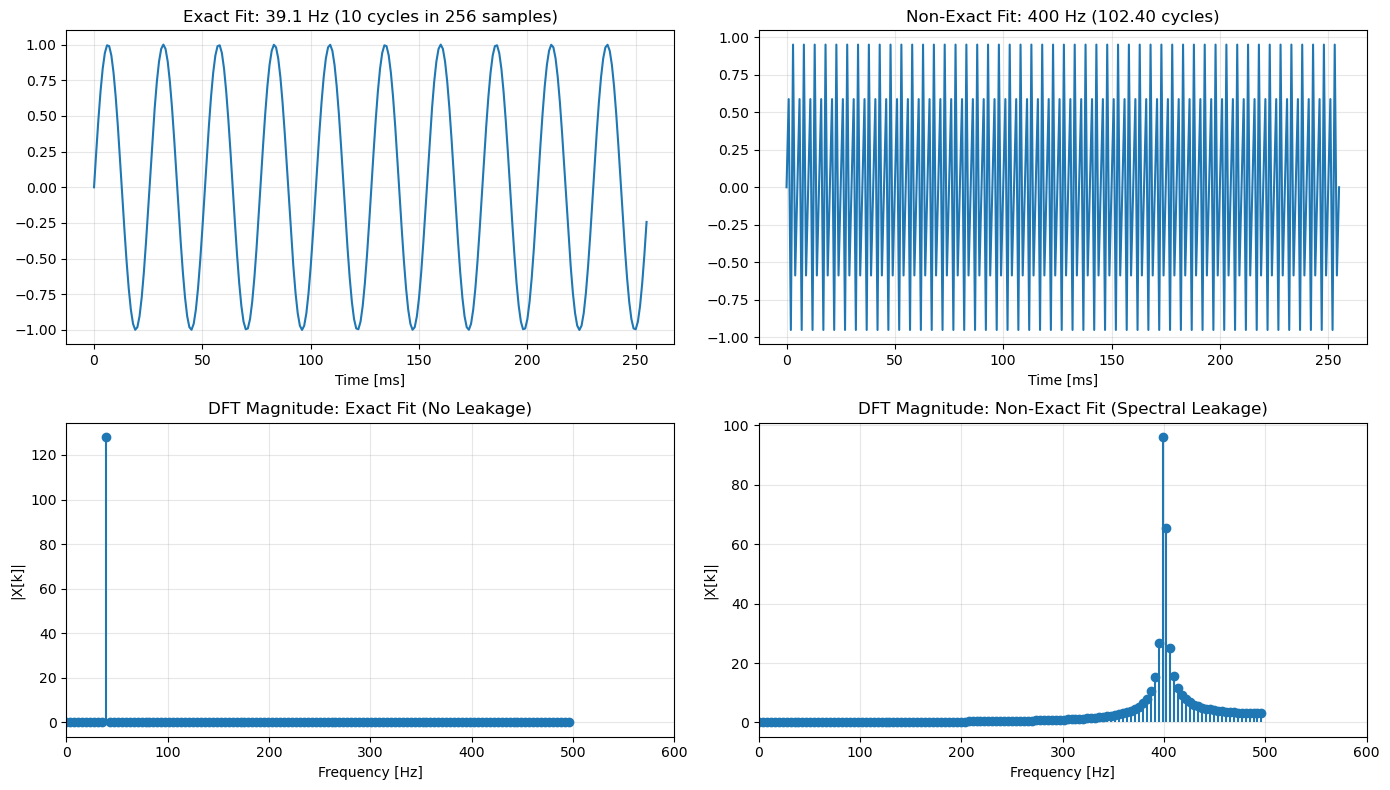

Frequency resolution (bin spacing): 3.91 Hz
Bin 10 corresponds to: 39.06 Hz


In [30]:
fs = 1000  # Sampling rate
N = 256    # Number of samples
t = np.arange(N) / fs

# Signal with exactly 10 cycles in N samples (fits perfectly in DFT window)
f_exact = 10 * fs / N  # = 390.625 Hz
x_exact = np.sin(2 * np.pi * f_exact * t)

# Signal that does NOT fit perfectly (causes leakage)
f_inexact = 400  # Hz
x_inexact = np.sin(2 * np.pi * f_inexact * t)

# Compute DFT
X_exact = fft(x_exact)
X_inexact = fft(x_inexact)
k = np.arange(N)
f_bins = k * fs / N  # Physical frequencies for bins 0 to N-1

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Time domain
axes[0, 0].plot(t * 1000, x_exact)
axes[0, 0].set_title(f'Exact Fit: {f_exact:.1f} Hz ({10} cycles in {N} samples)')
axes[0, 0].set_xlabel('Time [ms]')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t * 1000, x_inexact)
axes[0, 1].set_title(f'Non-Exact Fit: {f_inexact} Hz ({f_inexact * N / fs:.2f} cycles)')
axes[0, 1].set_xlabel('Time [ms]')
axes[0, 1].grid(True, alpha=0.3)

# Frequency domain (single-sided)
n_show = N // 2
axes[1, 0].stem(f_bins[:n_show], np.abs(X_exact)[:n_show], basefmt=' ')
axes[1, 0].set_title('DFT Magnitude: Exact Fit (No Leakage)')
axes[1, 0].set_xlabel('Frequency [Hz]')
axes[1, 0].set_ylabel('|X[k]|')
axes[1, 0].set_xlim(0, 600)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].stem(f_bins[:n_show], np.abs(X_inexact)[:n_show], basefmt=' ')
axes[1, 1].set_title('DFT Magnitude: Non-Exact Fit (Spectral Leakage)')
axes[1, 1].set_xlabel('Frequency [Hz]')
axes[1, 1].set_ylabel('|X[k]|')
axes[1, 1].set_xlim(0, 600)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Frequency resolution (bin spacing): {fs/N:.2f} Hz")
print(f"Bin 10 corresponds to: {10 * fs/N:.2f} Hz")


## 5. Conjugate Symmetry for Real Signals

If the input signal $x[n]$ is real-valued, the DFT exhibits **conjugate symmetry**:

$$X[k] = X^*[N-k]$$

This means:
- The magnitude spectrum is symmetric: $|X[k]| = |X[N-k]|$
- The phase spectrum is anti-symmetric: $\angle X[k] = -\angle X[N-k]$
- Only bins $0$ to $N/2$ carry unique information

This is why we typically plot only the single-sided spectrum for real signals.


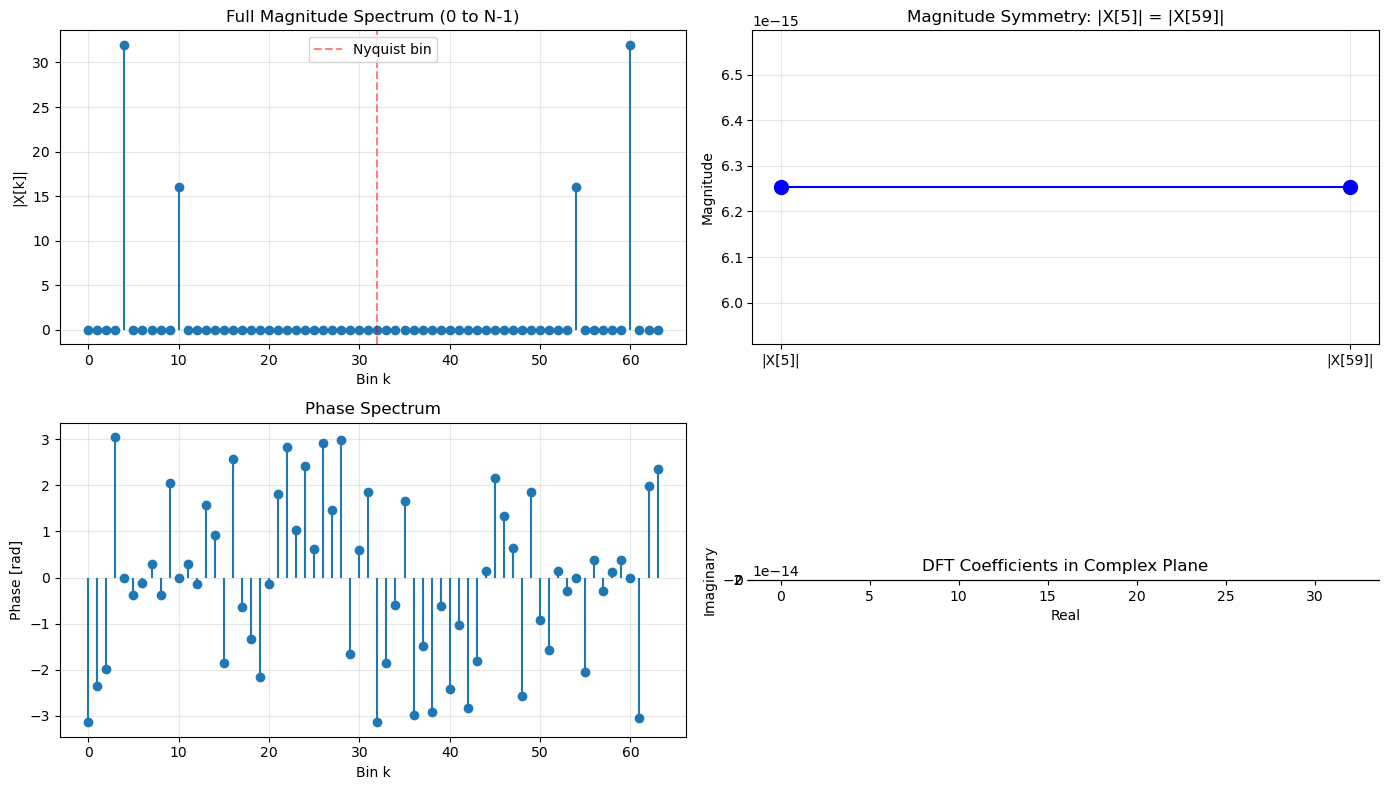

Conjugate symmetry holds: True


In [31]:
N = 64
n = np.arange(N)
x_real = np.cos(2 * np.pi * 4 * n / N) + 0.5 * np.cos(2 * np.pi * 10 * n / N)

X = fft(x_real)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Full magnitude spectrum
axes[0, 0].stem(np.arange(N), np.abs(X), basefmt=' ')
axes[0, 0].set_title('Full Magnitude Spectrum (0 to N-1)')
axes[0, 0].set_xlabel('Bin k')
axes[0, 0].set_ylabel('|X[k]|')
axes[0, 0].axvline(N/2, color='r', linestyle='--', alpha=0.5, label='Nyquist bin')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Verify symmetry: X[k] and X[N-k]
k_test = 5
axes[0, 1].plot([0, 1], [np.abs(X[k_test]), np.abs(X[N - k_test])], 'bo-', markersize=10)
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels([f'|X[{k_test}]|', f'|X[{N-k_test}]|'])
axes[0, 1].set_title(f'Magnitude Symmetry: |X[{k_test}]| = |X[{N-k_test}]|')
axes[0, 1].set_ylabel('Magnitude')
axes[0, 1].grid(True, alpha=0.3)

# Phase spectrum
phase = np.angle(X)
axes[1, 0].stem(np.arange(N), phase, basefmt=' ')
axes[1, 0].set_title('Phase Spectrum')
axes[1, 0].set_xlabel('Bin k')
axes[1, 0].set_ylabel('Phase [rad]')
axes[1, 0].grid(True, alpha=0.3)

# Complex plane: plot X[k] as points
for k in range(N):
    axes[1, 1].plot(np.real(X[k]), np.imag(X[k]), 'bo', markersize=4)
axes[1, 1].axhline(0, color='k', linewidth=0.5)
axes[1, 1].axvline(0, color='k', linewidth=0.5)
axes[1, 1].set_title('DFT Coefficients in Complex Plane')
axes[1, 1].set_xlabel('Real')
axes[1, 1].set_ylabel('Imaginary')
axes[1, 1].set_aspect('equal')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verify conjugate symmetry
symmetry_check = np.allclose(X[1:N//2], np.conj(X[N-1:N//2:-1]))
print(f"Conjugate symmetry holds: {symmetry_check}")


## 6. Inverse DFT and Perfect Reconstruction

The IDFT perfectly reconstructs the original signal (within numerical precision). Let's verify this and demonstrate what happens if we modify frequency coefficients before reconstruction.


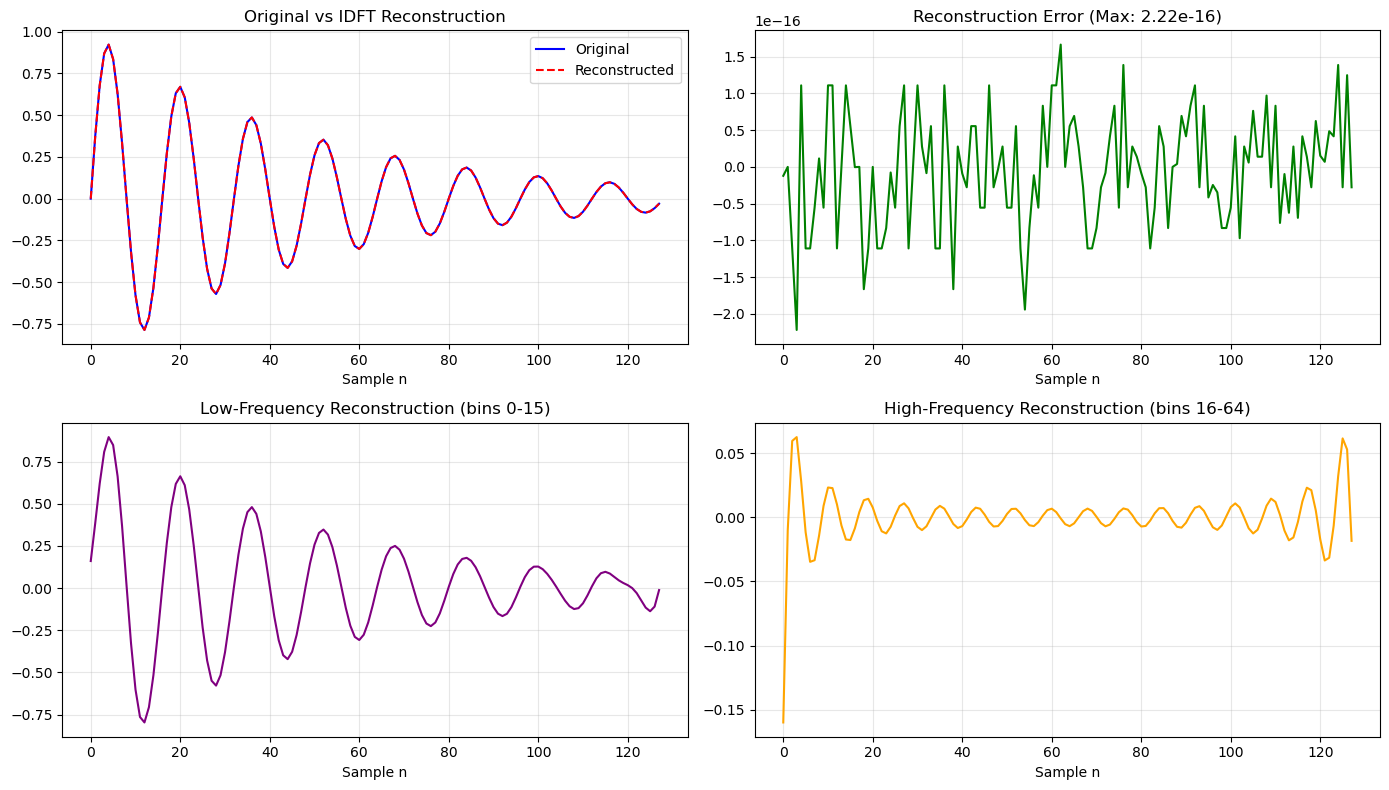

In [32]:
N = 128
n = np.arange(N)
x_orig = np.exp(-0.02 * n) * np.sin(2 * np.pi * 8 * n / N)

X = fft(x_orig)
x_recon = np.real(ifft(X))  # ifft returns complex, take real part

# Reconstruct with only low frequencies (low-pass in DFT domain)
X_low = X.copy()
cutoff_bin = 15
X_low[cutoff_bin+1:N-cutoff_bin] = 0
x_low = np.real(ifft(X_low))

# Reconstruct with only high frequencies
X_high = np.zeros_like(X)
X_high[cutoff_bin+1:N-cutoff_bin] = X[cutoff_bin+1:N-cutoff_bin]
x_high = np.real(ifft(X_high))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(n, x_orig, 'b-', label='Original')
axes[0, 0].plot(n, x_recon, 'r--', label='Reconstructed')
axes[0, 0].set_title('Original vs IDFT Reconstruction')
axes[0, 0].set_xlabel('Sample n')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(n, x_orig - x_recon, 'g-')
axes[0, 1].set_title(f'Reconstruction Error (Max: {np.max(np.abs(x_orig - x_recon)):.2e})')
axes[0, 1].set_xlabel('Sample n')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(n, x_low, 'purple')
axes[1, 0].set_title(f'Low-Frequency Reconstruction (bins 0-{cutoff_bin})')
axes[1, 0].set_xlabel('Sample n')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(n, x_high, 'orange')
axes[1, 1].set_title(f'High-Frequency Reconstruction (bins {cutoff_bin+1}-{N//2})')
axes[1, 1].set_xlabel('Sample n')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Circular Convolution Property

One of the most important DFT properties: **multiplication in the frequency domain corresponds to circular convolution in the time domain**.

$$(x \circledast h)[n] = \text{IDFT}\{X[k] \cdot H[k]\}$$

This is different from linear convolution. Circular convolution assumes periodicity, which causes **wrap-around effects** when signals are not zero-padded.


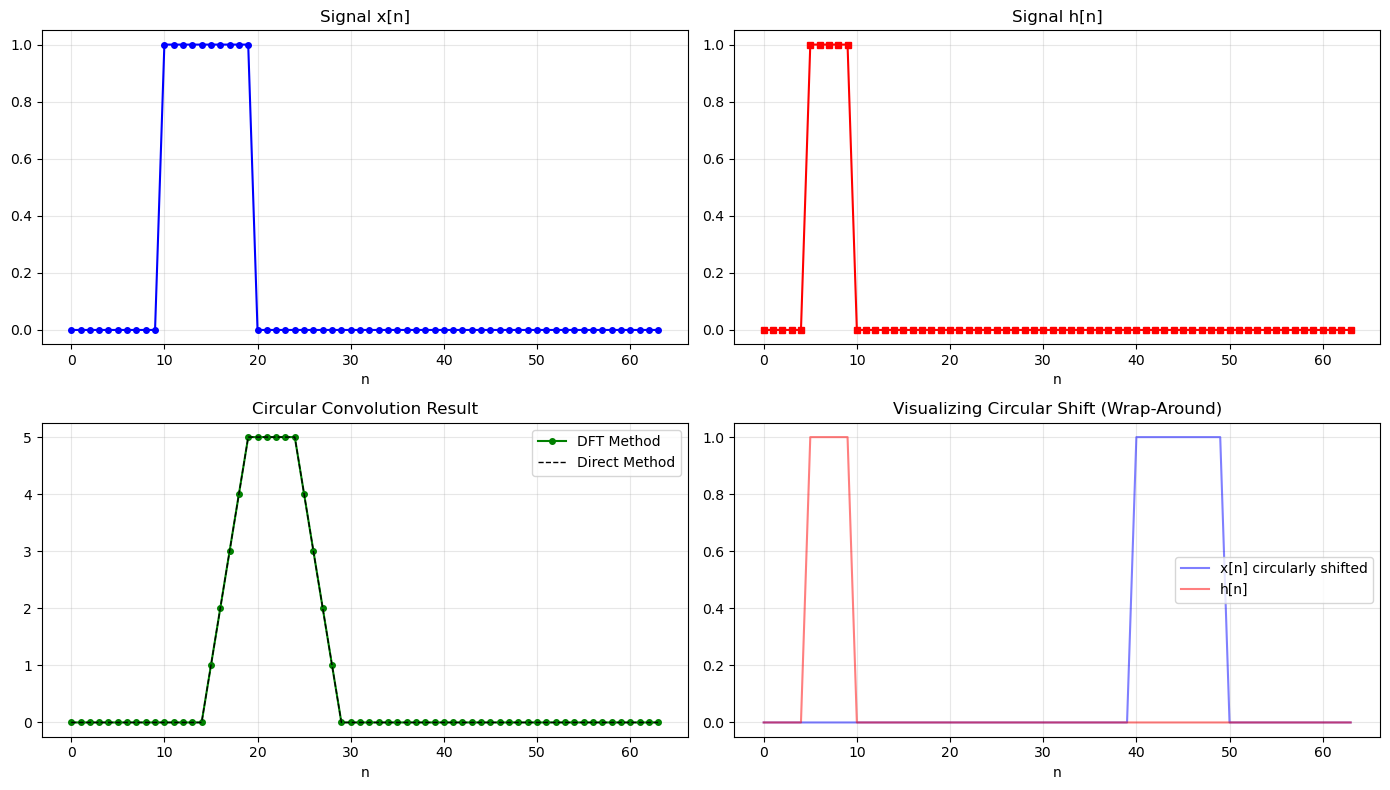

Circular convolution methods match: True


In [33]:
N = 64
x = np.zeros(N)
x[10:20] = 1  # Rectangular pulse
h = np.zeros(N)
h[5:10] = 1   # Smaller rectangular pulse

# Method 1: Circular convolution via DFT multiplication
X = fft(x)
H = fft(h)
y_circular = np.real(ifft(X * H))

# Method 2: Direct circular convolution
y_direct = np.zeros(N)
for n in range(N):
    for m in range(N):
        y_direct[n] += x[m] * h[(n - m) % N]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(x, 'b-o', markersize=4)
axes[0, 0].set_title('Signal x[n]')
axes[0, 0].set_xlabel('n')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(h, 'r-s', markersize=4)
axes[0, 1].set_title('Signal h[n]')
axes[0, 1].set_xlabel('n')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(y_circular, 'g-o', markersize=4, label='DFT Method')
axes[1, 0].plot(y_direct, 'k--', linewidth=1, label='Direct Method')
axes[1, 0].set_title('Circular Convolution Result')
axes[1, 0].set_xlabel('n')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Show wrap-around effect
axes[1, 1].plot(np.roll(x, 30), 'b-', alpha=0.5, label='x[n] circularly shifted')
axes[1, 1].plot(h, 'r-', alpha=0.5, label='h[n]')
axes[1, 1].set_title('Visualizing Circular Shift (Wrap-Around)')
axes[1, 1].set_xlabel('n')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Circular convolution methods match: {np.allclose(y_circular, y_direct)}")


## 8. Zero-Padding and Frequency Interpolation

Zero-padding in the time domain interpolates the DFT in the frequency domain. It does **not** improve true frequency resolution (which depends on observation time), but it produces a smoother-looking spectrum with more frequency samples.


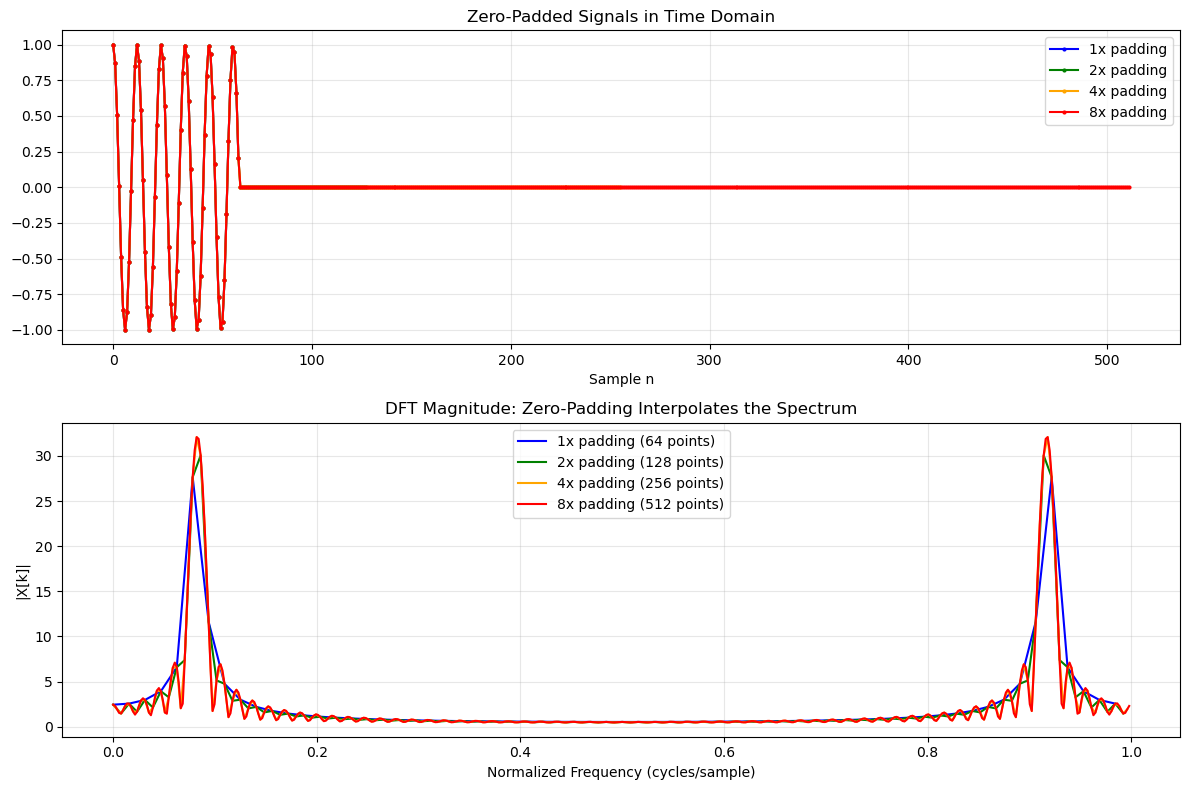

In [34]:
N = 64
n = np.arange(N)
x = np.cos(2 * np.pi * 5.3 * n / N)  # Non-integer cycles

# Different zero-padding levels
pad_factors = [1, 2, 4, 8]
colors = ['blue', 'green', 'orange', 'red']

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Time domain signals
for i, pad in enumerate(pad_factors):
    x_padded = np.pad(x, (0, N * (pad - 1)))
    t_padded = np.arange(len(x_padded))
    axes[0].plot(t_padded, x_padded, 'o-', markersize=2, label=f'{pad}x padding', color=colors[i])
axes[0].set_title('Zero-Padded Signals in Time Domain')
axes[0].set_xlabel('Sample n')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Frequency domain
for i, pad in enumerate(pad_factors):
    x_padded = np.pad(x, (0, N * (pad - 1)))
    X_padded = fft(x_padded)
    freqs = np.arange(len(X_padded)) / len(X_padded)
    axes[1].plot(freqs, np.abs(X_padded), '-', label=f'{pad}x padding ({len(X_padded)} points)', color=colors[i])

axes[1].set_title('DFT Magnitude: Zero-Padding Interpolates the Spectrum')
axes[1].set_xlabel('Normalized Frequency (cycles/sample)')
axes[1].set_ylabel('|X[k]|')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Windowing and Spectral Leakage

When a signal's frequency does not align exactly with a DFT bin, energy "leaks" into neighboring bins. Applying a window function tapers the signal at the edges, reducing leakage at the cost of slightly broadening the main lobe.

We compare the rectangular window (implicitly used) with the Hanning and Hamming windows.


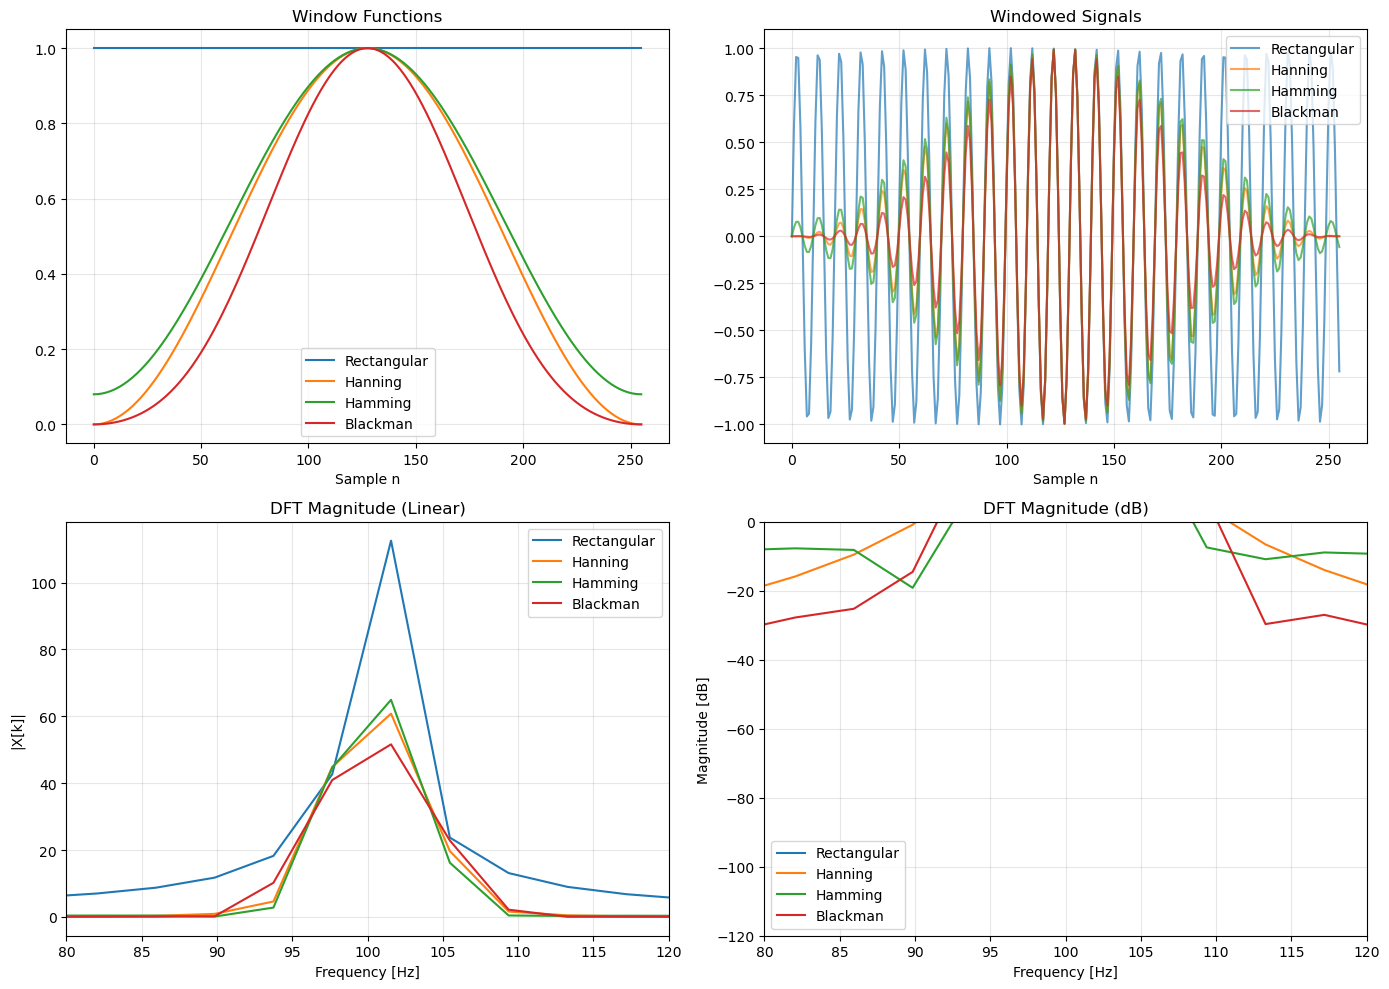

In [35]:
from scipy.signal import windows

N = 256
fs = 1000
n = np.arange(N)
f_signal = 100.5  # Falls between bins
x = np.sin(2 * np.pi * f_signal * n / fs)

window_types = {
    'Rectangular': windows.boxcar(N),
    'Hanning': windows.hann(N),
    'Hamming': windows.hamming(N),
    'Blackman': windows.blackman(N)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot windows
ax_win = axes[0, 0]
for name, win in window_types.items():
    ax_win.plot(win, label=name)
ax_win.set_title('Window Functions')
ax_win.set_xlabel('Sample n')
ax_win.legend()
ax_win.grid(True, alpha=0.3)

# Plot windowed signals
ax_sig = axes[0, 1]
for name, win in window_types.items():
    ax_sig.plot(x * win, alpha=0.7, label=name)
ax_sig.set_title('Windowed Signals')
ax_sig.set_xlabel('Sample n')
ax_sig.legend()
ax_sig.grid(True, alpha=0.3)

# DFT magnitudes (linear scale)
ax_lin = axes[1, 0]
for name, win in window_types.items():
    X = fft(x * win)
    freqs = fftfreq(N, 1/fs)
    ax_lin.plot(freqs[:N//2], np.abs(X)[:N//2], label=name)
ax_lin.set_title('DFT Magnitude (Linear)')
ax_lin.set_xlabel('Frequency [Hz]')
ax_lin.set_ylabel('|X[k]|')
ax_lin.set_xlim(80, 120)
ax_lin.legend()
ax_lin.grid(True, alpha=0.3)

# DFT magnitudes (dB scale)
ax_db = axes[1, 1]
for name, win in window_types.items():
    X = fft(x * win)
    freqs = fftfreq(N, 1/fs)
    mag_db = 20 * np.log10(np.abs(X)[:N//2] + 1e-12)
    ax_db.plot(freqs[:N//2], mag_db, label=name)
ax_db.set_title('DFT Magnitude (dB)')
ax_db.set_xlabel('Frequency [Hz]')
ax_db.set_ylabel('Magnitude [dB]')
ax_db.set_xlim(80, 120)
ax_db.set_ylim(-120, 0)
ax_db.legend()
ax_db.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. DFT of Common Signals

Let's examine the DFT of fundamental signal types: impulse, step, exponential, and random noise.


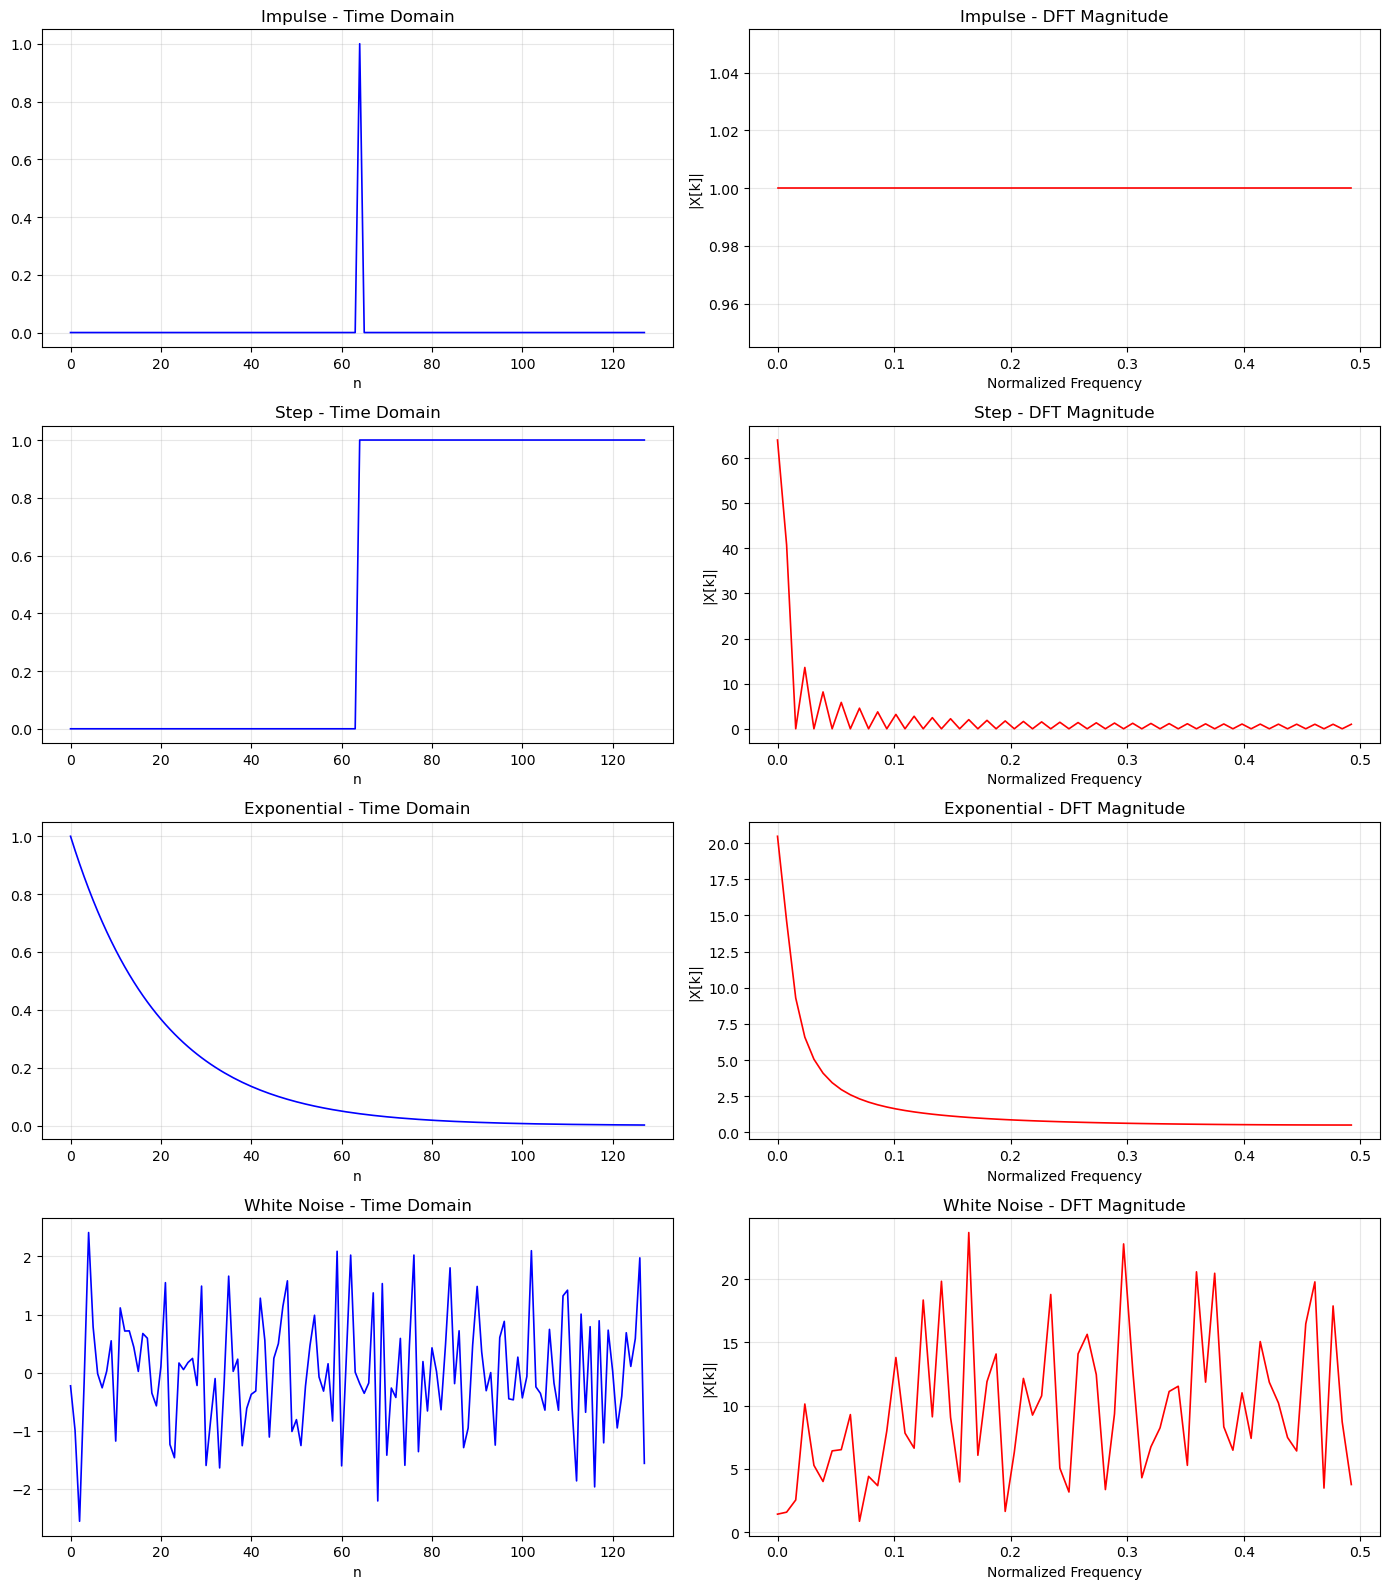

In [36]:
N = 128
n = np.arange(N)

signals = {
    'Impulse': np.where(n == N//2, 1, 0),
    'Step': np.where(n >= N//2, 1, 0),
    'Exponential': np.exp(-0.05 * n),
    'White Noise': np.random.randn(N)
}

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for i, (name, sig) in enumerate(signals.items()):
    X = fft(sig)
    freqs = fftfreq(N)
    
    # Time domain
    axes[i, 0].plot(n, sig, 'b-', linewidth=1.2)
    axes[i, 0].set_title(f'{name} - Time Domain')
    axes[i, 0].set_xlabel('n')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Frequency domain (magnitude)
    axes[i, 1].plot(freqs[:N//2], np.abs(X)[:N//2], 'r-', linewidth=1.2)
    axes[i, 1].set_title(f'{name} - DFT Magnitude')
    axes[i, 1].set_xlabel('Normalized Frequency')
    axes[i, 1].set_ylabel('|X[k]|')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Phase Unwrapping and Group Delay

The phase of the DFT is often wrapped to the range $(-\pi, \pi]$, causing discontinuities. **Phase unwrapping** removes these $2\pi$ jumps. For a linear-phase system, the negative derivative of the phase with respect to frequency gives the **group delay**.


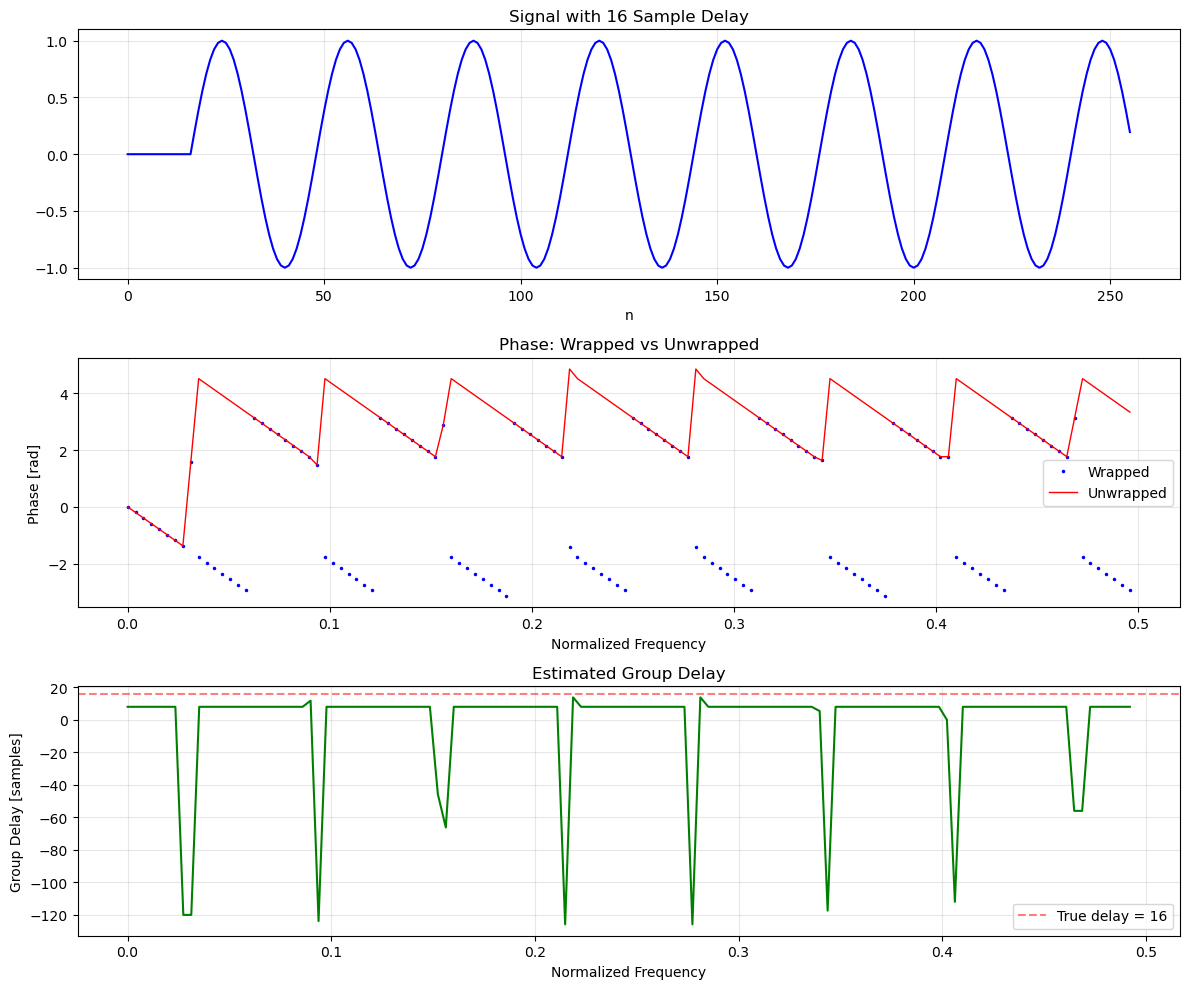

In [37]:
N = 256
n = np.arange(N)
# Create a signal with linear phase shift (delayed sine wave)
delay = 16
x_delayed = np.sin(2 * np.pi * 8 * (n - delay) / N)
x_delayed[:delay] = 0  # Causal signal

X = fft(x_delayed)
freqs = fftfreq(N)
phase_wrapped = np.angle(X)
phase_unwrapped = np.unwrap(phase_wrapped)

# Group delay (numerical derivative of unwrapped phase)
group_delay = -np.diff(phase_unwrapped) / (2 * np.pi * np.diff(freqs))

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(n, x_delayed, 'b-')
axes[0].set_title(f'Signal with {delay} Sample Delay')
axes[0].set_xlabel('n')
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs[:N//2], phase_wrapped[:N//2], 'b.', markersize=3, label='Wrapped')
axes[1].plot(freqs[:N//2], phase_unwrapped[:N//2], 'r-', linewidth=1, label='Unwrapped')
axes[1].set_title('Phase: Wrapped vs Unwrapped')
axes[1].set_xlabel('Normalized Frequency')
axes[1].set_ylabel('Phase [rad]')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(freqs[:N//2-1], group_delay[:N//2-1], 'g-')
axes[2].axhline(delay, color='r', linestyle='--', alpha=0.5, label=f'True delay = {delay}')
axes[2].set_title('Estimated Group Delay')
axes[2].set_xlabel('Normalized Frequency')
axes[2].set_ylabel('Group Delay [samples]')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

| Property | Description |
|----------|-------------|
| **Definition** | $X[k] = \sum_{n=0}^{N-1} x[n] W_N^{kn}$ |
| **Complexity** | Direct: $O(N^2)$; FFT: $O(N \log N)$ |
| **Frequency Bins** | $f_k = k \cdot f_s / N$ |
| **Symmetry** | Real $x[n] \Rightarrow X[k] = X^*[N-k]$ |
| **Periodicity** | DFT assumes $x[n]$ is periodic with period $N$ |
| **Leakage** | Occurs when signal frequency is not bin-centered |
| **Windowing** | Reduces leakage, broadens main lobe |
| **Zero-Padding** | Interpolates spectrum, does not add resolution |
| **Convolution** | Circular convolution via frequency-domain multiplication |
| **Phase** | Essential for reconstruction; unwrapping reveals linear trends |

The DFT is the workhorse of digital signal processing. Understanding its properties, limitations, and behavior with different signals is essential for any practical application.
